In [ ]:
import pandas as pd
df = pd.read_parquet(md.out_path)
if df.empty:
    raise RuntimeError("Dataset is empty.")

# Statistical tests: Basic setting experiments

## Statistical summary

In [ ]:
print("rows, cols:", df.shape)
print(df.describe(include="all").T)
print("\nMissing %:\n", (df.isna().mean().sort_values(ascending=False)*100).round(2))

rows, cols: (950, 10)
                 count        mean         std           min         25%  \
a                950.0    0.343581    0.156220  0.000000e+00    0.230321   
b                950.0    0.375138    0.143670  8.079500e-02    0.261826   
delta_ab         950.0    0.031557    0.018614  1.563318e-02    0.023053   
dim              950.0    1.000000    0.000000  1.000000e+00    1.000000   
sample_id        950.0   24.500000   14.438471  0.000000e+00   12.000000   
num_eigs         950.0  518.058947  319.175186  0.000000e+00  239.500000   
nz_eig1          900.0    2.546396    2.894651  3.752722e-08    0.198062   
nz_eig2          900.0    3.558977    3.568171  1.819825e-06    0.463219   
nz_eig3          900.0    3.962646    3.712848  6.690299e-06    0.646372   
dC1_edges_added  900.0   57.590000    4.478314  4.600000e+01   55.000000   

                        50%         75%          max  
a                  0.361997    0.474216     0.580973  
b                  0.386800    

**Load and drop rows where eigs are missing**

In [ ]:
df = df.dropna(subset=["nz_eig1","nz_eig2","nz_eig3"])

**Distributions**

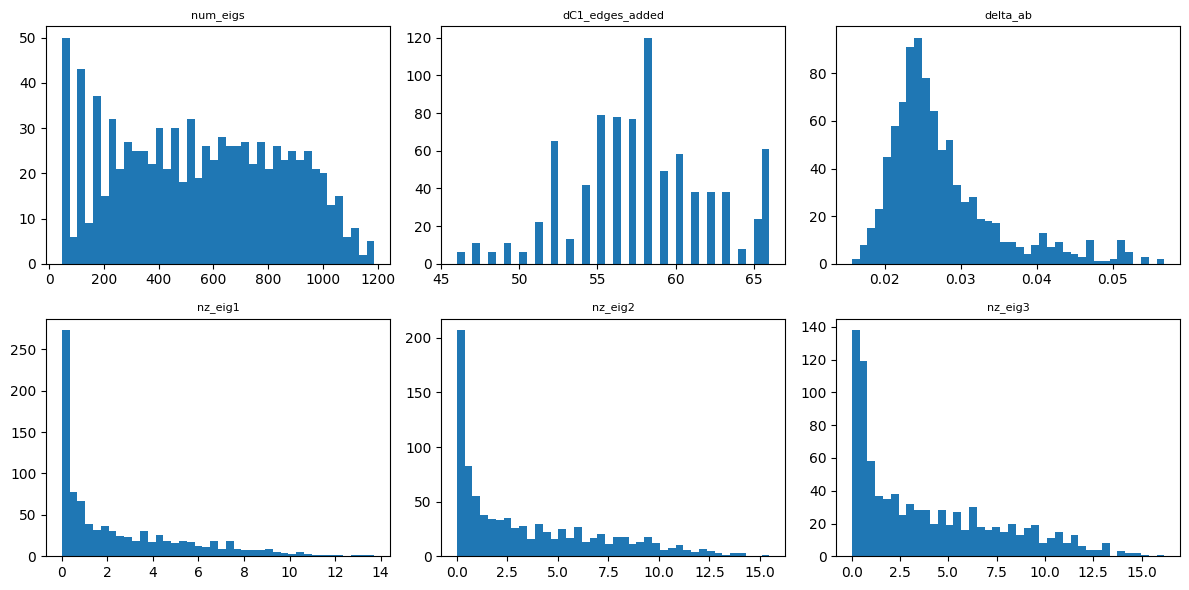

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

cols = ["num_eigs", "dC1_edges_added", "delta_ab", "nz_eig1", "nz_eig2", "nz_eig3"]

fig, ax = plt.subplots(2, 3, figsize=(12, 6))
for a, c in zip(ax.ravel(), cols):
    a.hist(df[c].dropna(), bins=40)
    a.set_title(c, fontsize=8)

plt.tight_layout()
plt.show()

### Plot a agains C1 added and C1 size

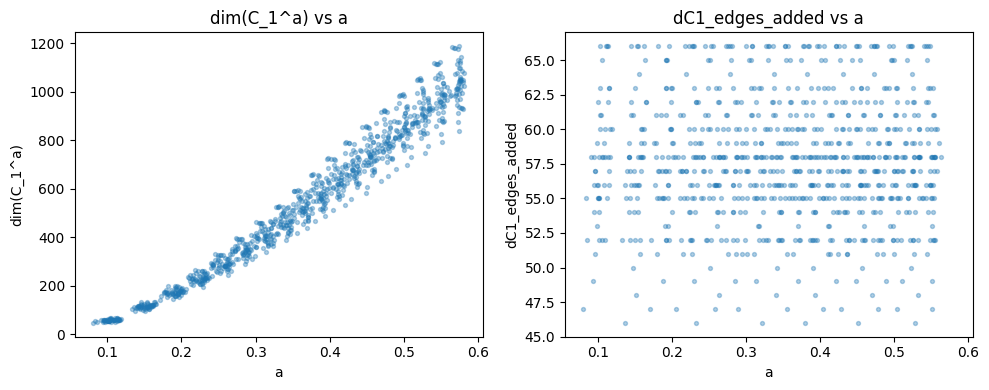

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

ax[0].scatter(df["a"], df["num_eigs"], s=8, alpha=0.35)
ax[0].set_title("dim(C_1^a) vs a")
ax[0].set_xlabel("a")
ax[0].set_ylabel("dim(C_1^a)")

ax[1].scatter(df["a"], df["dC1_edges_added"], s=8, alpha=0.35)
ax[1].set_title("dC1_edges_added vs a")
ax[1].set_xlabel("a")
ax[1].set_ylabel("dC1_edges_added")

plt.tight_layout()
plt.show()

## Scatter plots

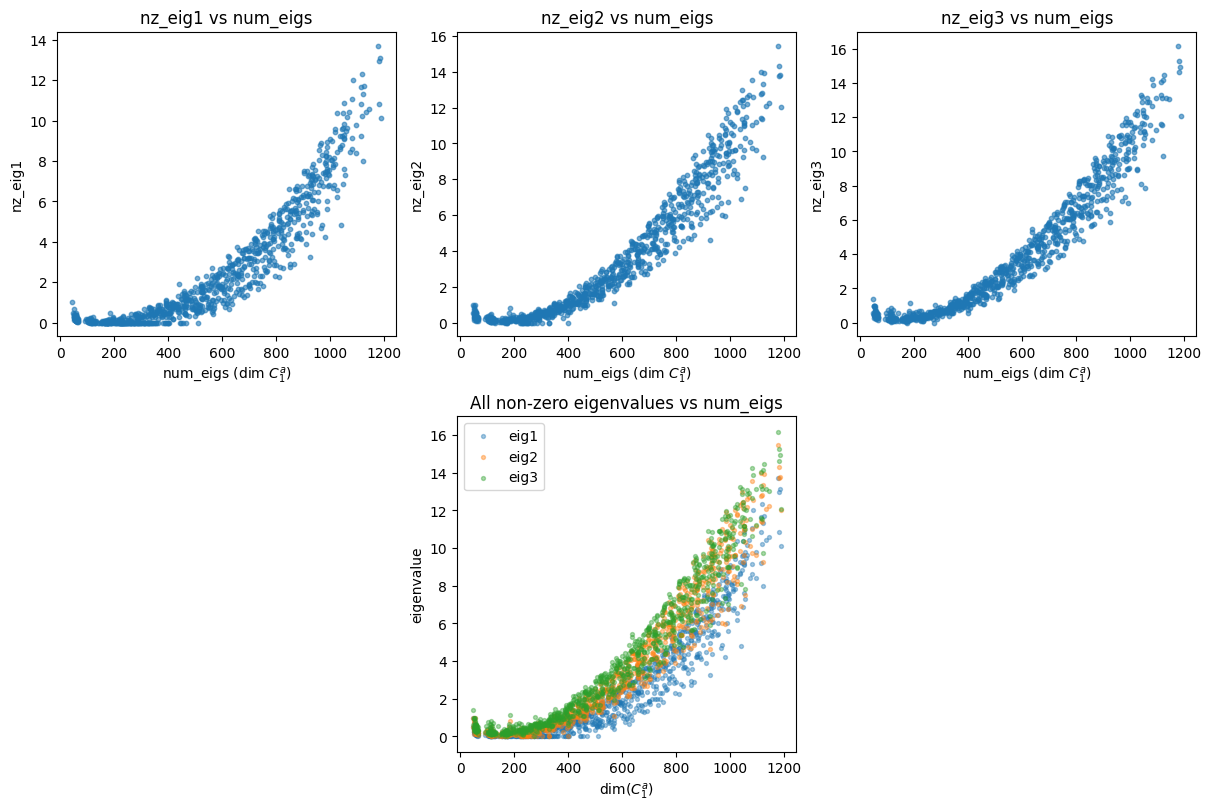

In [ ]:
import matplotlib.pyplot as plt

# Data columns
eig_cols = ["nz_eig1", "nz_eig2", "nz_eig3"]
eig_labels = ["eig1", "eig2", "eig3"]


fig = plt.figure(figsize=(12, 8), constrained_layout=True)
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1.1])


axes_top = [fig.add_subplot(gs[0, i]) for i in range(3)]

for ax, eig in zip(axes_top, eig_cols):
    ax.scatter(df["num_eigs"], df[eig], s=10, alpha=0.6)
    ax.set_xlabel("num_eigs (dim $C_1^a$)")
    ax.set_ylabel(eig)
    ax.set_title(f"{eig} vs num_eigs")

ax_bottom = fig.add_subplot(gs[1, 1])  

for eig, label in zip(eig_cols, eig_labels):
    ax_bottom.scatter(df["num_eigs"], df[eig], s=8, alpha=0.4, label=label)

ax_bottom.set_xlabel("dim($C_1^a$)")
ax_bottom.set_ylabel("eigenvalue")
ax_bottom.set_title("All non-zero eigenvalues vs num_eigs")
ax_bottom.legend()

plt.show()

Maybe
- exponential
-  variance increase
- spread tighten at larger eigenvalues
- I think it is more linear as we move to bigger eigenvalues

It is closer to exponential.

Maybe is just that the eigenvalue value increase as is a bigger eigenvalues and that adds to the influence of the input space size.

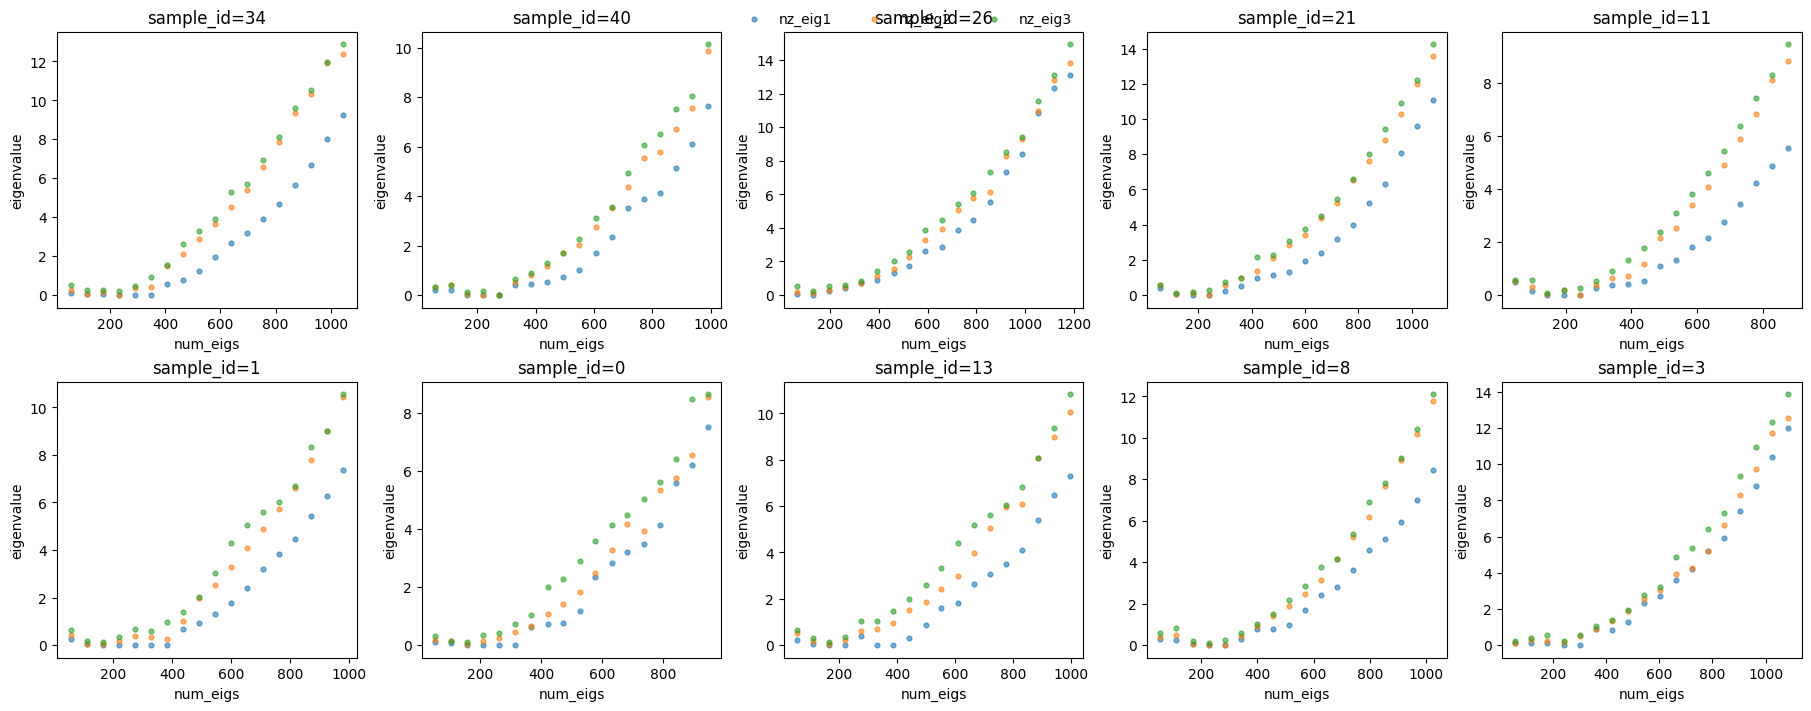

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


id_col = "sample_id"  
n_ids = 10
rng = np.random.default_rng(0)  

ids = df[id_col].dropna().unique()
if len(ids) < n_ids:
    raise ValueError(f"Not enough unique ids in '{id_col}': {len(ids)} < {n_ids}")

picked_ids = rng.choice(ids, size=n_ids, replace=False)

xcol = "num_eigs"
eig_cols = ["nz_eig1", "nz_eig2", "nz_eig3"]


fig, axes = plt.subplots(2, 5, figsize=(18, 7), constrained_layout=True)
axes = axes.ravel()

for ax, sid in zip(axes, picked_ids):
    d = df[df[id_col] == sid]
    
    for eig in eig_cols:
        ax.scatter(d[xcol], d[eig], s=12, alpha=0.6, label=eig)

    ax.set_title(f"{id_col}={sid}")
    ax.set_xlabel(xcol)
    ax.set_ylabel("eigenvalue")

# show legend once
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(eig_cols), frameon=False)

plt.show()

**What is the law of growth?**

In [ ]:
import numpy as np
import statsmodels.api as sm

def test_growth_laws(df, eig_col):
    # Remove zeros / negatives
    sub = df[df[eig_col] > 0].copy()

    y = sub[eig_col].values
    S = sub["num_eigs"].values

    results = {}

    # Linear
    X = sm.add_constant(S)
    model = sm.OLS(y, X).fit()
    results["linear"] = model.rsquared

    # Log-linear
    X = sm.add_constant(np.log(S))
    model = sm.OLS(y, X).fit()
    results["log-linear"] = model.rsquared

    # Power law
    X = sm.add_constant(np.log(S))
    model = sm.OLS(np.log(y), X).fit()
    results["power-law"] = model.rsquared

    # Exponential
    X = sm.add_constant(S)
    model = sm.OLS(np.log(y), X).fit()
    results["exponential"] = model.rsquared

    return results

for eig in ["nz_eig1", "nz_eig2", "nz_eig3"]:
    res = test_growth_laws(df, eig)
    print(f"\n{eig}")
    for k, v in res.items():
        print(f"{k:12s} R^2 = {v:.4f}")


nz_eig1
linear       R^2 = 0.8016
log-linear   R^2 = 0.5143
power-law    R^2 = 0.2874
exponential  R^2 = 0.3960

nz_eig2
linear       R^2 = 0.8622
log-linear   R^2 = 0.5822
power-law    R^2 = 0.3978
exponential  R^2 = 0.4800

nz_eig3
linear       R^2 = 0.8822
log-linear   R^2 = 0.6063
power-law    R^2 = 0.6820
exponential  R^2 = 0.7824


## Simple correlation

**Proxy correlation**

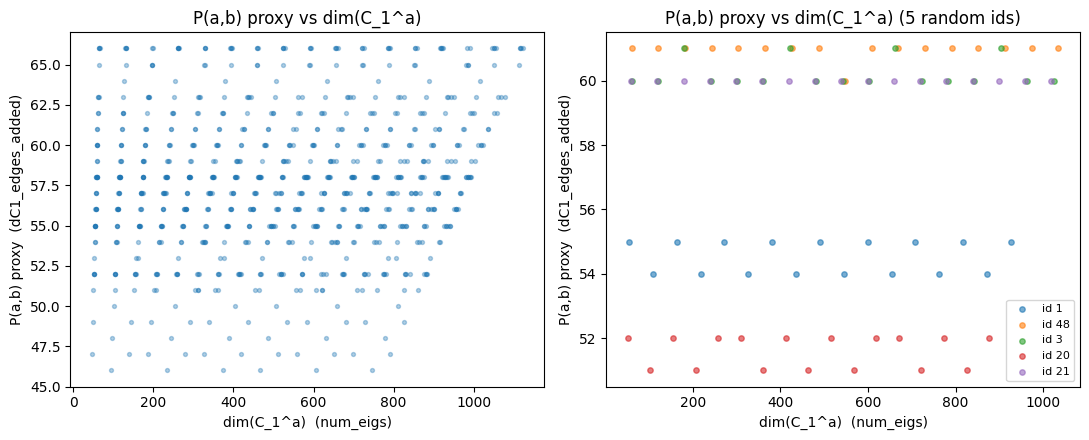

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


all_ids = df["sample_id"].unique()
ids = np.random.choice(all_ids, size=5, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: all points
axes[0].scatter(df["num_eigs"], df["dC1_edges_added"], s=8, alpha=0.35)
axes[0].set_title("P(a,b) proxy vs dim(C_1^a)")
axes[0].set_xlabel("dim(C_1^a)  (num_eigs)")
axes[0].set_ylabel("P(a,b) proxy  (dC1_edges_added)")

# Right: 5 random ids
cmap = plt.get_cmap("tab10")
for i, id_val in enumerate(ids):
    subset = df[df["sample_id"] == id_val]
    axes[1].scatter(
        subset["num_eigs"],
        subset["dC1_edges_added"],
        s=15,
        alpha=0.6,
        color=cmap(i),
        label=f"id {id_val}"
    )

axes[1].set_title("P(a,b) proxy vs dim(C_1^a) (5 random ids)")
axes[1].set_xlabel("dim(C_1^a)  (num_eigs)")
axes[1].set_ylabel("P(a,b) proxy  (dC1_edges_added)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

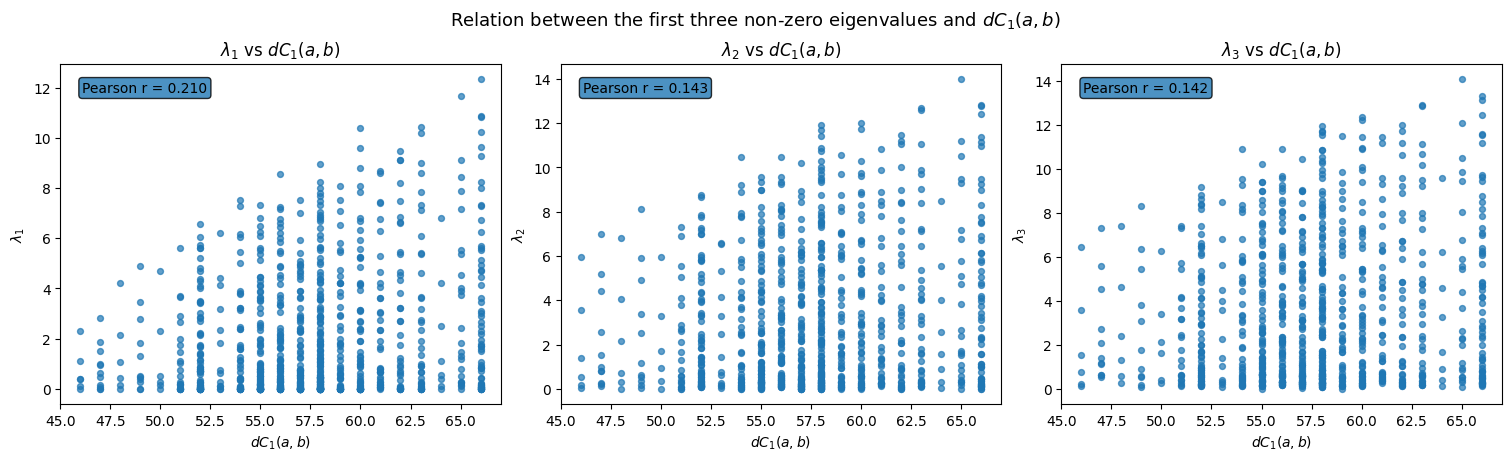

Pearson correlations with dC1_edges_added:

nz_eig1    0.210
nz_eig2    0.143
nz_eig3    0.142
Name: dC1_edges_added, dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

proxy_col = "dC1_edges_added"
targets = ["nz_eig1", "nz_eig2", "nz_eig3"]
pretty_names = {
    "nz_eig1": r"$\lambda_1$",
    "nz_eig2": r"$\lambda_2$",
    "nz_eig3": r"$\lambda_3$",
}

# Keep only needed columns
sub = df[[proxy_col] + targets].dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

for ax, ycol in zip(axes, targets):
    x = sub[proxy_col].to_numpy()
    y = sub[ycol].to_numpy()

    r = np.corrcoef(x, y)[0, 1]

    ax.scatter(x, y, s=18, alpha=0.7)
    ax.set_xlabel(r"$dC_1(a,b)$")
    ax.set_ylabel(pretty_names[ycol])
    ax.set_title(f"{pretty_names[ycol]} vs $dC_1(a,b)$")

    ax.text(
        0.05, 0.95, f"Pearson r = {r:.3f}",
        transform=ax.transAxes,
        va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.25", alpha=0.8)
    )

fig.suptitle("Relation between the first three non-zero eigenvalues and $dC_1(a,b)$", fontsize=13)
plt.show()

corr_series = sub[[proxy_col] + targets].corr(method="pearson").loc[proxy_col, targets]
print("Pearson correlations with dC1_edges_added:\n")
print(corr_series.round(3))

- All the variables except the delta_ab are highly correlated with each other
- Higher the eigenvalue more determined by the variables.
- Also the eigenvalues are correlated with highly correlated each other.
- Since we made the experiment increasing the size this make sense.

# Other not useful experiments

## Multiple regresion

nz_eig1
  R2 = 0.8785
  coef = {'a': np.float64(-39.8804), 'b': np.float64(23.3779), 'delta_ab': np.float64(63.2583), 'num_eigs': np.float64(0.0172)}
  intercept = -3.2742



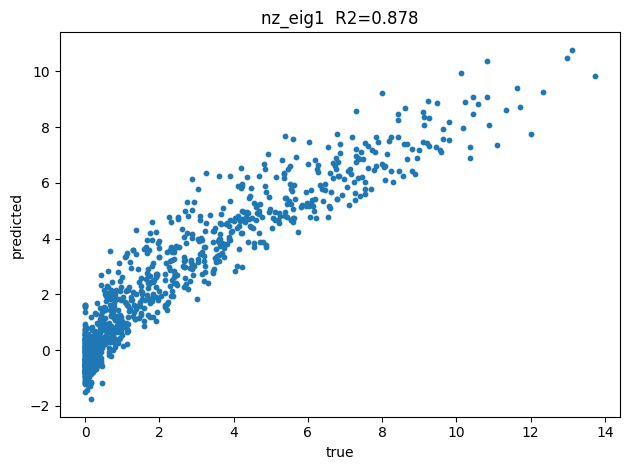

nz_eig2
  R2 = 0.9075
  coef = {'a': np.float64(-43.4919), 'b': np.float64(36.653), 'delta_ab': np.float64(80.145), 'num_eigs': np.float64(0.0158)}
  intercept = -5.806



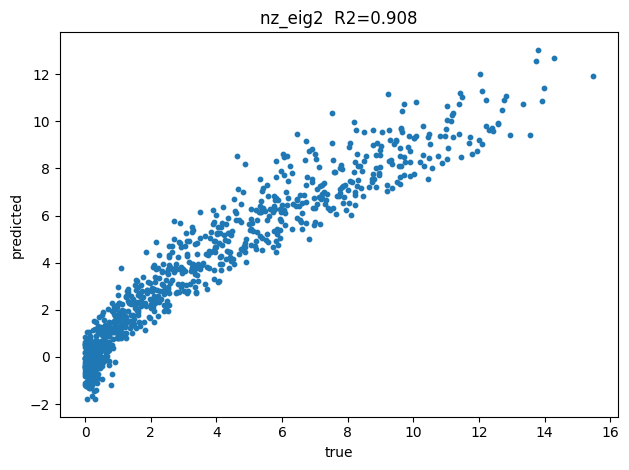

nz_eig3
  R2 = 0.922
  coef = {'a': np.float64(-42.2652), 'b': np.float64(35.3892), 'delta_ab': np.float64(77.6543), 'num_eigs': np.float64(0.0163)}
  intercept = -5.5773



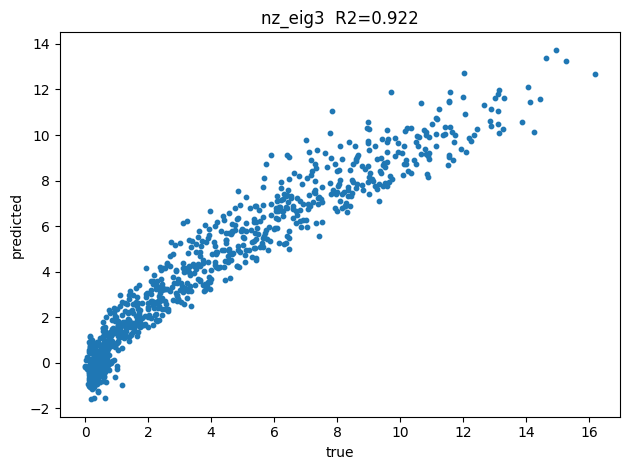

In [ ]:
# regress_eigs.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score



# Predictors: everything except eigenvalues
X = df[["a","b","delta_ab","num_eigs"]].to_numpy()

for target in ["nz_eig1","nz_eig2","nz_eig3"]:
    y = df[target].to_numpy()

    model = LinearRegression().fit(X, y)
    yhat = model.predict(X)

    print(f"{target}")
    print("  R2 =", round(r2_score(y, yhat), 4))
    print("  coef =", dict(zip(["a","b","delta_ab","num_eigs"], 
                                np.round(model.coef_,4))))
    print("  intercept =", round(model.intercept_,4))
    print()

    # Plot true vs predicted
    plt.figure()
    plt.scatter(y, yhat, s=10)
    plt.xlabel("true")
    plt.ylabel("predicted")
    plt.title(f"{target}  R2={r2_score(y,yhat):.3f}")
    plt.tight_layout()
    plt.show()
